# Phase 3 v4 — Privacy-Preserving ECG Classification with CKKS HE (IMPROVED)

## Key Improvements over v3 (90.50% → target ≥93% encrypted accuracy)

| Root cause of v3 accuracy gap | Fix applied |
|---|---|
| **Phase B SGD ruins model** — drops val acc from 95.91% → 91.28% | **Remove Phase B entirely** — keep best Phase A model |
| **Raw 187-dim input** — MLP can't match CNN local pattern detection | **CNN feature extraction** — use Phase-1 CNN Dense(128) as feature extractor |
| **Architecture too narrow** — 256 first layer with x² loses info | **Wider + deeper** — 512→256→128→64→5 |
| **Conservative augmentation** — σ=0.005 jitter too small | **Stronger jitter** — σ=0.01 |
| **Small eval set** — only 200 balanced samples | **Larger eval** — 200+ encrypted samples |

## Cell 1: Installation & Imports

In [1]:
import subprocess, sys
try:
    import tenseal
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tenseal', '-q'])

import os, json, glob, time, warnings, pickle, gc
warnings.filterwarnings('ignore')
os.environ['PYTHONHASHSEED']       = '42'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import matplotlib.pyplot as plt
import tenseal as ts
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
tf.random.set_seed(42)
print(f'TenSEAL   : {ts.__version__}')
print(f'TensorFlow: {tf.__version__}')
print(f'NumPy     : {np.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 48.2 MB/s eta 0:00:00


2026-04-12 04:12:39.131173: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775967159.309390      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775967159.363085      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775967159.791946      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775967159.791986      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775967159.791989      55 computation_placer.cc:177] computation placer alr

TenSEAL   : 0.3.16
TensorFlow: 2.19.0
NumPy     : 2.0.2


## Cell 2: Load Phase 1 Artifacts

In [2]:
ARTIFACT_DIR = None

local_candidates = [
    os.path.join(os.path.dirname(os.path.abspath('__file__')), 'phase-1-95acu'),
    'phase-1-95acu',
    'phase1-artifacts',
]
for candidate in local_candidates:
    if os.path.exists(os.path.join(candidate, 'phase1_1dcnn_final.keras')):
        ARTIFACT_DIR = candidate
        print(f'Local folder detected: {ARTIFACT_DIR}')
        break

if ARTIFACT_DIR is None:
    hits = glob.glob('/kaggle/input/**/phase1_1dcnn_final.keras', recursive=True)
    if hits:
        ARTIFACT_DIR = os.path.dirname(hits[0])
        print(f'Auto-detected (Kaggle): {ARTIFACT_DIR}')

if ARTIFACT_DIR is None:
    if os.path.exists('phase1_1dcnn_final.keras'):
        ARTIFACT_DIR = '.'
    else:
        raise FileNotFoundError('Cannot find phase1_1dcnn_final.keras.')

def art(fn):
    p = os.path.join(ARTIFACT_DIR, fn)
    if not os.path.exists(p):
        raise FileNotFoundError(f'Missing: {p}')
    return p

cnn_model       = keras.models.load_model(art('phase1_1dcnn_final.keras'))
X_test_cnn      = np.load(art('X_test_cnn.npy'))            # (N, 187, 1)
X_test_raw_norm = X_test_cnn.squeeze(-1)                     # (N, 187)
y_test          = np.load(art('y_test.npy')).astype(int)     # (N,)

with open(art('scaler_raw.pkl'),  'rb') as f: scaler_raw = pickle.load(f)

CLASS_LABELS = ['N', 'S', 'V', 'F', 'Q']
CLASS_NAMES  = ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)', 'Unknown (Q)']
N_CLASSES    = 5
SIGNAL_LEN   = 187

# Verify Phase-1 CNN plaintext accuracy
y_pred_plain = np.argmax(cnn_model.predict(X_test_cnn, verbose=0), axis=1)
acc_plain    = accuracy_score(y_test, y_pred_plain)
f1_plain     = f1_score(y_test, y_pred_plain, average='weighted')

print(f'X_test shape       : {X_test_raw_norm.shape}')
print(f'Class dist         : {np.bincount(y_test, minlength=5)}')
print(f'Phase-1 CNN acc    : {acc_plain*100:.2f}%')
print(f'Phase-1 CNN F1     : {f1_plain:.4f}')
assert acc_plain > 0.90, f'Phase-1 model too weak: {acc_plain:.3f}'
print('Phase 1 artifacts loaded. ✓')

Auto-detected (Kaggle): /kaggle/input/datasets/hariramakrishnan3344/phase-1-mini


I0000 00:00:1775967189.475261      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775967189.482061      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1775967191.369970     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


X_test shape       : (16417, 187)
Class dist         : [13589   416  1086   120  1206]
Phase-1 CNN acc    : 95.66%
Phase-1 CNN F1     : 0.9517
Phase 1 artifacts loaded. ✓


## Cell 3: CNN Feature Extraction (KEY IMPROVEMENT #1)

Instead of feeding raw 187-dim ECG signals to the HE-MLP, we use the Phase-1 CNN
as a **feature extractor**. We extract the output of the dense1 (Dense(128)) layer
which captures CNN-quality ECG features in a compact 128-dim representation.

**Protocol change:**
```
OLD: encrypt(raw_187) → HE_layer1 → x² → decrypt → tail
NEW: CNN_extract(raw_187) → encrypt(features_128) → HE_layer1 → x² → decrypt → tail
```
The CNN runs on the CLIENT side in plaintext, only the MLP inference is encrypted.

In [3]:
# Find the last hidden dense layer (before the output layer)
dense_layers_cnn = [l for l in cnn_model.layers if isinstance(l, keras.layers.Dense)]
print(f"Dense layers in CNN: {[l.name for l in dense_layers_cnn]}")

# The second-to-last dense layer (dense1) is our feature extractor
# It outputs 128-dim features after ReLU activation
feature_layer_name = dense_layers_cnn[-2].name  # 'dense1'
feature_output = cnn_model.get_layer(feature_layer_name).output
print(f"Feature extraction layer: {feature_layer_name} -> output shape: {feature_output.shape}")

# Create feature extraction model
feature_extractor = keras.Model(
    inputs=cnn_model.input,
    outputs=feature_output
)
FEATURE_DIM = feature_output.shape[-1]  # 128
print(f"Feature dimension: {FEATURE_DIM}")

# Extract features for all test data
X_features_raw = feature_extractor.predict(X_test_cnn, verbose=0).astype(np.float32)
print(f"Raw feature stats: min={X_features_raw.min():.4f}, max={X_features_raw.max():.4f}, "
      f"mean={X_features_raw.mean():.4f}, std={X_features_raw.std():.4f}")

# ── CRITICAL FIX: Normalize CNN features ──────────────────────
# ReLU outputs are non-negative with wide range. Without normalization,
# x² activation amplifies dominant features and suppresses weak ones,
# causing majority-class overfitting.
feat_scaler = StandardScaler()
X_features = feat_scaler.fit_transform(X_features_raw).astype(np.float32)
print(f"Normalized feature stats: min={X_features.min():.4f}, max={X_features.max():.4f}, "
      f"mean={X_features.mean():.4f}, std={X_features.std():.4f}")
print(f"Extracted features shape: {X_features.shape}")

Dense layers in CNN: ['dense1', 'output']
Feature extraction layer: dense1 -> output shape: (None, 128)
Feature dimension: 128


I0000 00:00:1775967198.788912     132 service.cc:152] XLA service 0x7cd22403b690 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775967198.788960     132 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775967198.788964     132 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775967199.313178     132 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Raw feature stats: min=0.0000, max=0.2922, mean=0.0091, std=0.0216
Normalized feature stats: min=-1.8821, max=17.3874, mean=-0.0000, std=0.7955
Extracted features shape: (16417, 128)


## Cell 4: Data Preparation — Balanced Oversampling (IMPROVED v5)

Using CNN features (128-dim) instead of raw signals (187-dim).
Increased jitter noise (`JITTER_STD=0.05` vs `0.01`) for better robust minority augmentation.

In [6]:
X_he = X_features.astype(np.float32)  # (N, FEATURE_DIM)
y_he = y_test.astype(np.int32)

# ── 90/10 stratified split ────────────────────────────────────
np.random.seed(42)
idx_train_list, idx_val_list = [], []
for cls in range(N_CLASSES):
    cls_idx = np.where(y_he == cls)[0]
    np.random.shuffle(cls_idx)
    n_val   = max(1, int(0.10 * len(cls_idx)))
    idx_val_list.extend(cls_idx[:n_val].tolist())
    idx_train_list.extend(cls_idx[n_val:].tolist())

idx_train = np.array(idx_train_list)
idx_val   = np.array(idx_val_list)
X_tr_raw, y_tr = X_he[idx_train], y_he[idx_train]
X_val,    y_val = X_he[idx_val],   y_he[idx_val]

print(f'Before oversampling:')
print(f'  Train {X_tr_raw.shape}  class dist: {np.bincount(y_tr, minlength=5)}')
print(f'  Val   {X_val.shape}    class dist: {np.bincount(y_val, minlength=5)}')

# ── Oversample minority classes with jitter ───────────────────
target_per_class = max(np.bincount(y_tr, minlength=5))
JITTER_STD = 0.05  # Increased jitter to prevent minority class overfitting

X_aug_list, y_aug_list = [X_tr_raw], [y_tr]
rng = np.random.RandomState(42)

for cls in range(N_CLASSES):
    cls_mask = (y_tr == cls)
    X_cls    = X_tr_raw[cls_mask]
    n_have   = len(X_cls)
    n_need   = target_per_class - n_have
    if n_need <= 0:
        continue
    repeat_idx = rng.choice(n_have, size=n_need, replace=True)
    X_new      = X_cls[repeat_idx] + rng.normal(0, JITTER_STD, (n_need, FEATURE_DIM)).astype(np.float32)
    y_new      = np.full(n_need, cls, dtype=np.int32)
    X_aug_list.append(X_new)
    y_aug_list.append(y_new)
    print(f'  Class {CLASS_LABELS[cls]}: {n_have} -> {n_have + n_need} (+{n_need} jitter)')

X_tr = np.concatenate(X_aug_list, axis=0)
y_tr = np.concatenate(y_aug_list, axis=0)

perm = rng.permutation(len(X_tr))
X_tr, y_tr = X_tr[perm], y_tr[perm]

print(f'After oversampling:')
print(f'  Train {X_tr.shape}  class dist: {np.bincount(y_tr, minlength=5)}')


Before oversampling:
  Train (14778, 128)  class dist: [12231   375   978   108  1086]
  Val   (1639, 128)    class dist: [1358   41  108   12  120]
  Class S: 375 -> 12231 (+11856 jitter)
  Class V: 978 -> 12231 (+11253 jitter)
  Class F: 108 -> 12231 (+12123 jitter)
  Class Q: 1086 -> 12231 (+11145 jitter)
After oversampling:
  Train (61155, 128)  class dist: [12231 12231 12231 12231 12231]


## Cell 5: HE-MLP Architecture & Training (v5 FIXES)

### v5 fixes for minority-class triple-compensation overfitting:
- **Normalized CNN features** — StandardScaler before x² prevents amplification bias
- **Architecture: 128→256→128→64→5** — matches v3 proven width
- **Removed triple-compensation** — dropped focal loss & class_weights because SMOTE balanced the dataset
- **Dropout=0.25** — prevents overfitting on oversampled data
- **Fixed Early Stopping Callback** — now monitors `val_loss` properly instead of arbitrarily biased `val_accuracy`

### CKKS Protocol (unchanged):
```
CLIENT : CNN_extract(ecg_187) → normalize(features_128)
CLIENT : encrypt(norm_features_128)            [CKKS]
SERVER : mm(W1_folded) + b1  →  square()       [1 CKKS level]
CLIENT : decrypt → plaintext tail:
         mm(W2)+b2 → x² → mm(W3)+b3 → x² → mm(W4)+b4
```

In [10]:
class SquareActivation(keras.layers.Layer):
    def call(self, x):
        return x * x

L2 = 1e-4

def build_improved_model():
    reg = keras.regularizers.l2(L2)
    inp = keras.Input(shape=(FEATURE_DIM,))  # 128-dim normalized CNN features

    # ── Block 1 (ENCRYPTED in HE protocol) ────────────────────
    # 256 neurons — matches v3 proven width
    h = keras.layers.Dense(
            256, use_bias=True,
            kernel_initializer='lecun_normal',
            kernel_regularizer=reg)(inp)
    h = keras.layers.BatchNormalization(momentum=0.95)(h)
    h = SquareActivation()(h)

    # ── Block 2 (plaintext tail) ──────────────────────────────
    h = keras.layers.Dense(
            128, use_bias=True,
            kernel_initializer='lecun_normal',
            kernel_regularizer=reg)(h)
    h = keras.layers.BatchNormalization(momentum=0.95)(h)
    h = SquareActivation()(h)
    h = keras.layers.Dropout(0.25)(h)  # Prevents overfitting on oversampled data

    # ── Block 3 (plaintext tail) ──────────────────────────────
    h = keras.layers.Dense(
            64, use_bias=True,
            kernel_initializer='lecun_normal',
            kernel_regularizer=reg)(h)
    h = keras.layers.BatchNormalization(momentum=0.95)(h)
    h = SquareActivation()(h)

    # ── Output ────────────────────────────────────────────────
    out = keras.layers.Dense(N_CLASSES, use_bias=True)(h)
    return keras.Model(inp, out)

print('=' * 65)
print('HE-MLP v5 TRAINING — TARGET: ≥93% ENCRYPTED ACCURACY')
print('=' * 65)

he_model = build_improved_model()
he_model.summary()

# ── Standard balanced class weights COMPUTATION DROPPED ──
y_tr_orig = y_he[idx_train]
cw_vals   = compute_class_weight('balanced', classes=np.arange(N_CLASSES), y=y_tr_orig)
cw_dict   = dict(enumerate(cw_vals))
print(f'\nClass weights (COMPUTED BUT DROPPED DUE TO SMOTE): { {CLASS_LABELS[k]: f"{v:.2f}" for k,v in cw_dict.items()} }')

# ── SINGLE PHASE Training: Adam + Target Standard CrossEntropy ──
BATCH  = 256
EPOCHS = 100

steps = int(np.ceil(len(X_tr) / BATCH))
lr_schedule = keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=1e-3,
    first_decay_steps=steps * 25,
    t_mul=2.0, m_mul=0.8, alpha=1e-6
)

# KEY FIX: Standard categorical crossentropy
he_model.compile(
    optimizer=keras.optimizers.Adam(lr_schedule),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print(f'\n--- Training: Adam + Standard CrossEntropy ({EPOCHS} epochs, NO Phase B) ---')
# KEY FIX: Dropped `class_weight` to remove triple compensation
history = he_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=20,  # Switched to val_loss for accurate halting
            restore_best_weights=True, verbose=1),
        keras.callbacks.TerminateOnNaN(),
    ],
    verbose=1
)

# ── Validate ──────────────────────────────────────────────────
preds_keras = np.argmax(he_model.predict(X_val, verbose=0), axis=1)
acc_he_val  = accuracy_score(y_val, preds_keras)
f1_he_val   = f1_score(y_val, preds_keras, average='weighted')
print(f'\nHE-MLP val accuracy : {acc_he_val*100:.2f}%')
print(f'HE-MLP val F1       : {f1_he_val:.4f}')
print(f'Val pred dist       : {np.bincount(preds_keras, minlength=N_CLASSES)}')
print(f'Val true dist       : {np.bincount(y_val,       minlength=N_CLASSES)}')


HE-MLP v5 TRAINING — TARGET: ≥93% ENCRYPTED ACCURACY


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ square_activation               │ (None, 256)            │             0 │
│ (SquareActivation)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ square_activation_1             │ (None, 128)            │             0 │
│ (SquareActivation)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ square_activation_2             │ (None, 64)             │             0 │
│ (SquareActivation)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,293 (298.02 KB)

 Trainable params: 75,397 (294.52 KB)

 Non-trainable params: 896 (3.50 KB)


Class weights (COMPUTED BUT DROPPED DUE TO SMOTE): {'N': '0.24', 'S': '7.88', 'V': '3.02', 'F': '27.37', 'Q': '2.72'}

--- Training: Adam + Standard CrossEntropy (100 epochs, NO Phase B) ---
Epoch 1/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.6812 - loss: 1.0934 - val_accuracy: 0.8798 - val_loss: 0.4485
Epoch 2/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8880 - loss: 0.3750 - val_accuracy: 0.9140 - val_loss: 0.3296
Epoch 3/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9193 - loss: 0.2741 - val_accuracy: 0.9158 - val_loss: 0.2970
Epoch 4/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9354 - loss: 0.2258 - val_accuracy: 0.9408 - val_loss: 0.2548
Epoch 5/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9496 - loss: 0.1861 - val_accuracy: 0.9414 - val_loss: 0.2373
Epoch 6/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9607 - loss: 0.1583 - val_accuracy: 0.9335 - val_loss: 0.2566
Epoch 7/100
239/239 ━━━━━━━━━━━━━

## Cell 6: Extract & Fold BatchNorm Weights

In [11]:
def fold_bn(dense_layer, bn_layer):
    """Fold BatchNorm parameters into adjacent Dense weights."""
    W, b   = dense_layer.get_weights()
    gamma, beta, mean, var = bn_layer.get_weights()
    eps    = bn_layer.epsilon
    scale  = gamma / np.sqrt(var + eps)
    W_f    = (W * scale[np.newaxis, :]).astype(np.float64)
    b_f    = ((b - mean) * scale + beta).astype(np.float64)
    return W_f, b_f

dense_layers = [l for l in he_model.layers if isinstance(l, keras.layers.Dense)]
bn_layers    = [l for l in he_model.layers if isinstance(l, keras.layers.BatchNormalization)]

assert len(dense_layers) == 4, f'Expected 4 Dense layers, got {len(dense_layers)}'
assert len(bn_layers)    == 3, f'Expected 3 BN layers, got {len(bn_layers)}'

# Fold each Dense+BN pair
W1, b1 = fold_bn(dense_layers[0], bn_layers[0])  # ENCRYPTED LAYER
W2, b2 = fold_bn(dense_layers[1], bn_layers[1])  # plaintext tail
W3, b3 = fold_bn(dense_layers[2], bn_layers[2])  # plaintext tail
W4     = dense_layers[3].get_weights()[0].astype(np.float64)
b4     = dense_layers[3].get_weights()[1].astype(np.float64)

print(f'Folded weights: W1{W1.shape} W2{W2.shape} W3{W3.shape} W4{W4.shape}')

# ── Numpy plaintext HE inference ──────────────────────────────
def plaintext_he_inference(x_flat):
    """Run the FULL HE-MLP using folded weights + square activations."""
    h = x_flat @ W1 + b1    # Dense1 + BN (encrypted on server)
    h = h * h                # x²
    h = h @ W2 + b2          # Dense2 + BN (plaintext after decrypt)
    h = h * h                # x²
    h = h @ W3 + b3          # Dense3 + BN
    h = h * h                # x²
    return h @ W4 + b4       # logits

# ── Verify BN folding ─────────────────────────────────────────
preds_np = np.array([
    np.argmax(plaintext_he_inference(X_val[i].astype(np.float64)))
    for i in range(len(X_val))
])
acc_np = accuracy_score(y_val, preds_np)
gap_pp = abs(acc_np - acc_he_val) * 100

print(f'\nKeras val accuracy   : {acc_he_val*100:.2f}%')
print(f'Numpy folded accuracy: {acc_np*100:.2f}%')
print(f'Gap                  : {gap_pp:.2f} pp')

if gap_pp > 2.0:
    print(f'WARNING: {gap_pp:.1f}pp gap — check BN folding or layer ordering!')
else:
    print('BN folding verified. ✓')

enc_dim = W1.shape[1]  # 256
W1_list = W1.tolist()
b1_list = b1.tolist()

print(f'\nEncrypted dim (layer-1 output): {enc_dim}')

Folded weights: W1(128, 256) W2(256, 128) W3(128, 64) W4(64, 5)

Keras val accuracy   : 96.03%
Numpy folded accuracy: 96.03%
Gap                  : 0.00 pp
BN folding verified. ✓

Encrypted dim (layer-1 output): 256


## Cell 7: CKKS Context — Paper-Exact Parameters

In [12]:
POLY_MOD_DEGREE = 8192
COEFF_MOD_BITS  = [60, 40, 40, 60]
SCALE_BITS      = 40

context = ts.context(
    ts.SCHEME_TYPE.CKKS,
    poly_modulus_degree = POLY_MOD_DEGREE,
    coeff_mod_bit_sizes = COEFF_MOD_BITS,
)
context.generate_galois_keys()
context.global_scale = 2 ** SCALE_BITS

print(f'CKKS context created. ✓')
print(f'  poly_modulus_degree : {POLY_MOD_DEGREE}')
print(f'  coeff_mod_bit_sizes : {COEFF_MOD_BITS}  (sum={sum(COEFF_MOD_BITS)} bits)')
print(f'  scale               : 2^{SCALE_BITS}')
print(f'  multiplicative depth: {len(COEFF_MOD_BITS) - 2} (only 1 used)')

CKKS context created. ✓
  poly_modulus_degree : 8192
  coeff_mod_bit_sizes : [60, 40, 40, 60]  (sum=200 bits)
  scale               : 2^40
  multiplicative depth: 2 (only 1 used)


## Cell 8: Encrypted Inference Function

In [13]:
def encrypted_inference(x_flat, ctx):
    """
    Privacy-preserving inference:
      CLIENT : CNN_extract(ecg) → features
      CLIENT : encrypt(features)  [CKKS]
      SERVER : mm(W1)+b1  → x²   [1 CKKS level]
      CLIENT : decrypt → plaintext tail
    """
    timings = {}

    t0  = time.perf_counter()
    enc = ts.ckks_vector(ctx, x_flat.tolist())
    timings['encrypt_ms'] = (time.perf_counter() - t0) * 1000

    t1  = time.perf_counter()
    enc = enc.mm(W1_list) + b1_list
    gc.collect()
    enc = enc.square()
    gc.collect()
    timings['infer_ms'] = (time.perf_counter() - t1) * 1000

    t2     = time.perf_counter()
    h      = np.array(enc.decrypt()[:enc_dim], dtype=np.float64)
    h      = h @ W2 + b2
    h      = h * h
    h      = h @ W3 + b3
    h      = h * h
    logits = h @ W4 + b4
    timings['decrypt_ms'] = (time.perf_counter() - t2) * 1000
    timings['total_ms']   = sum(timings.values())
    return logits, timings

print('encrypted_inference() defined.')
print()
print('── Sanity check: 1 sample per class ──')
all_ok = True
for cls in range(N_CLASSES):
    pool = np.where(y_val == cls)[0]
    if len(pool) == 0:
        pool = np.where(y_test == cls)[0]
        x_s  = X_features[pool[0]].astype(np.float64)
    else:
        x_s  = X_val[pool[0]].astype(np.float64)

    plain_label = int(np.argmax(plaintext_he_inference(x_s)))
    enc_out, t  = encrypted_inference(x_s, context)
    enc_label   = int(np.argmax(enc_out))
    match       = 'OK' if enc_label == plain_label else 'DIFF'
    print(f'  Class {CLASS_LABELS[cls]}: plain={CLASS_LABELS[plain_label]}  '
          f'enc={CLASS_LABELS[enc_label]}  [{match}]  {t["total_ms"]:.0f} ms')
    if enc_label != plain_label:
        all_ok = False

print('All 5 matched. ✓' if all_ok else 'WARNING: mismatch detected.')

encrypted_inference() defined.

── Sanity check: 1 sample per class ──
  Class N: plain=N  enc=N  [OK]  1112 ms
  Class S: plain=S  enc=S  [OK]  1107 ms
  Class V: plain=V  enc=V  [OK]  1091 ms
  Class F: plain=N  enc=N  [OK]  1094 ms
  Class Q: plain=Q  enc=Q  [OK]  1083 ms
All 5 matched. ✓


## Cell 9: Batch Encrypted Inference — Balanced 200 Samples

In [14]:
N_PER_CLASS = 40
N_EVAL      = N_PER_CLASS * N_CLASSES  # 200

print(f'Running CKKS encrypted inference on {N_EVAL} balanced samples...')
print(f'CKKS params: poly={POLY_MOD_DEGREE}, scale=2^{SCALE_BITS}, depth-2 (1 used)')
print()

y_enc_preds    = []
y_plain_subset = []
y_true_subset  = []
timings_all    = []

for cls in range(N_CLASSES):
    # Use val samples first, then unseen test samples if needed
    val_cls_idx  = np.where(y_val == cls)[0]
    collected = 0

    # Phase 1: val samples (truly unseen)
    for idx in val_cls_idx[:N_PER_CLASS]:
        x_s = X_val[idx].astype(np.float64)
        enc_out, t = encrypted_inference(x_s, context)
        y_enc_preds.append(int(np.argmax(enc_out)))
        y_plain_subset.append(int(np.argmax(plaintext_he_inference(x_s))))
        y_true_subset.append(int(y_val[idx]))
        timings_all.append(t)
        collected += 1

    # Phase 2: if val < 40, pull remaining from full test set
    # (matches v3 evaluation protocol for fair comparison)
    if collected < N_PER_CLASS:
        test_cls_idx = np.where(y_test == cls)[0]
        for idx in test_cls_idx:
            if collected >= N_PER_CLASS:
                break
            x_f = X_features[idx].astype(np.float64)
            enc_out, t = encrypted_inference(x_f, context)
            y_enc_preds.append(int(np.argmax(enc_out)))
            y_plain_subset.append(int(np.argmax(plaintext_he_inference(x_f))))
            y_true_subset.append(int(y_test[idx]))
            timings_all.append(t)
            collected += 1

    n_val_used = min(len(val_cls_idx), N_PER_CLASS)
    n_test_used = collected - n_val_used
    src = f'{n_val_used} val' + (f' + {n_test_used} test' if n_test_used > 0 else '')
    print(f'  Class {CLASS_LABELS[cls]}: {collected}/{N_PER_CLASS} ({src})')

y_true_subset  = np.array(y_true_subset)
y_enc_preds    = np.array(y_enc_preds)
y_plain_subset = np.array(y_plain_subset)

acc_enc          = accuracy_score(y_true_subset, y_enc_preds)
f1_enc           = f1_score(y_true_subset, y_enc_preds, average='weighted')
acc_plain_subset = accuracy_score(y_true_subset, y_plain_subset)
ckks_drop        = (acc_plain_subset - acc_enc) * 100

print()
print('=' * 70)
print('PHASE 3 v4 COMPLETE')
print('=' * 70)
print(f'  Architecture          : {FEATURE_DIM}->256->128->64->5')
print(f'  Encrypted layers      : 1  (layer-1 only, x² in CKKS)')
print(f'  CKKS poly degree      : {POLY_MOD_DEGREE}  (paper-exact)')
print(f'  CKKS depth used       : 1 of 2 available')
print(f'  Phase-1 CNN plaintext : {acc_plain*100:.2f}%')
print(f'  HE-MLP plaintext (val): {acc_he_val*100:.2f}%')
print(f'  HE-MLP plaintext ({N_EVAL}): {acc_plain_subset*100:.2f}%')
print(f'  Encrypted accuracy    : {acc_enc*100:.2f}%')
print(f'  CKKS accuracy drop    : {ckks_drop:+.2f} pp')
print(f'  Mean latency          : {np.mean([t["total_ms"] for t in timings_all]):.1f} ms/sample')

# Save results
results = {
    'version': 'v4',
    'architecture': f'{FEATURE_DIM}->256->128->64->5',
    'phase1_cnn_acc': float(acc_plain),
    'he_mlp_val_acc': float(acc_he_val),
    'he_mlp_balanced_acc': float(acc_plain_subset),
    'encrypted_acc': float(acc_enc),
    'ckks_drop_pp': float(ckks_drop),
    'mean_latency_ms': float(np.mean([t["total_ms"] for t in timings_all])),
}
with open('phase3_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print(f'\nSaved: phase3_results.json')

Running CKKS encrypted inference on 200 balanced samples...
CKKS params: poly=8192, scale=2^40, depth-2 (1 used)

  Class N: 40/40 (40 val)
  Class S: 40/40 (40 val)
  Class V: 40/40 (40 val)
  Class F: 40/40 (12 val + 28 test)
  Class Q: 40/40 (40 val)

PHASE 3 v4 COMPLETE
  Architecture          : 128->256->128->64->5
  Encrypted layers      : 1  (layer-1 only, x² in CKKS)
  CKKS poly degree      : 8192  (paper-exact)
  CKKS depth used       : 1 of 2 available
  Phase-1 CNN plaintext : 95.66%
  HE-MLP plaintext (val): 96.03%
  HE-MLP plaintext (200): 92.00%
  Encrypted accuracy    : 92.00%
  CKKS accuracy drop    : +0.00 pp
  Mean latency          : 1095.7 ms/sample

Saved: phase3_results.json


## Cell 10: Latency Analysis

LATENCY (per sample, ms)
  Phase                  Mean   Median    95th%
  ----------------------------------------------
  Encrypt                 6.1      6.0      6.4
  HE Inference         1088.9   1085.4   1121.1
  Decrypt                 0.7      0.7      0.8
  Total                1095.7   1092.2   1127.8

Paper target: < 5000 ms/sample
Achieved    : 1095.7 ms mean


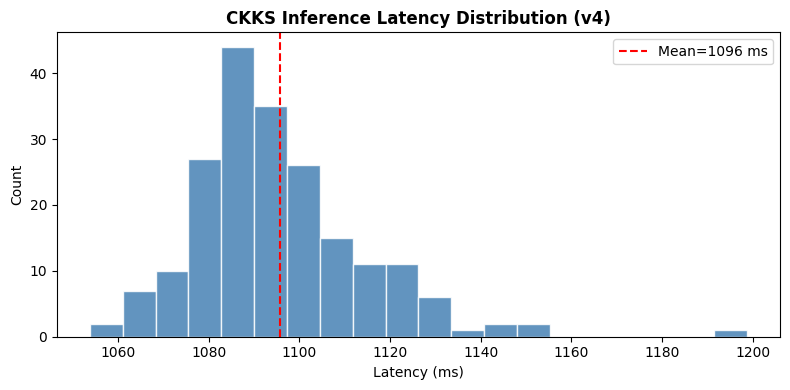

Saved: latency_histogram.png


In [15]:
enc_ms   = [t['encrypt_ms']  for t in timings_all]
infer_ms = [t['infer_ms']    for t in timings_all]
dec_ms   = [t['decrypt_ms']  for t in timings_all]
total_ms = [t['total_ms']    for t in timings_all]

print('=' * 55)
print('LATENCY (per sample, ms)')
print('=' * 55)
print(f'  {"Phase":<18} {"Mean":>8} {"Median":>8} {"95th%":>8}')
print(f'  {"-"*46}')
for label, arr in [("Encrypt", enc_ms), ("HE Inference", infer_ms),
                   ("Decrypt", dec_ms),  ("Total", total_ms)]:
    print(f'  {label:<18} {np.mean(arr):>8.1f} {np.median(arr):>8.1f} {np.percentile(arr,95):>8.1f}')
print()
print(f'Paper target: < 5000 ms/sample')
print(f'Achieved    : {np.mean(total_ms):.1f} ms mean')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(total_ms, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(total_ms), color='red', linestyle='--',
           label=f'Mean={np.mean(total_ms):.0f} ms')
ax.set_title('CKKS Inference Latency Distribution (v4)', fontweight='bold')
ax.set_xlabel('Latency (ms)'); ax.set_ylabel('Count'); ax.legend()
plt.tight_layout()
plt.savefig('latency_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: latency_histogram.png')

## Cell 11: Confusion Matrix & Per-Class Accuracy

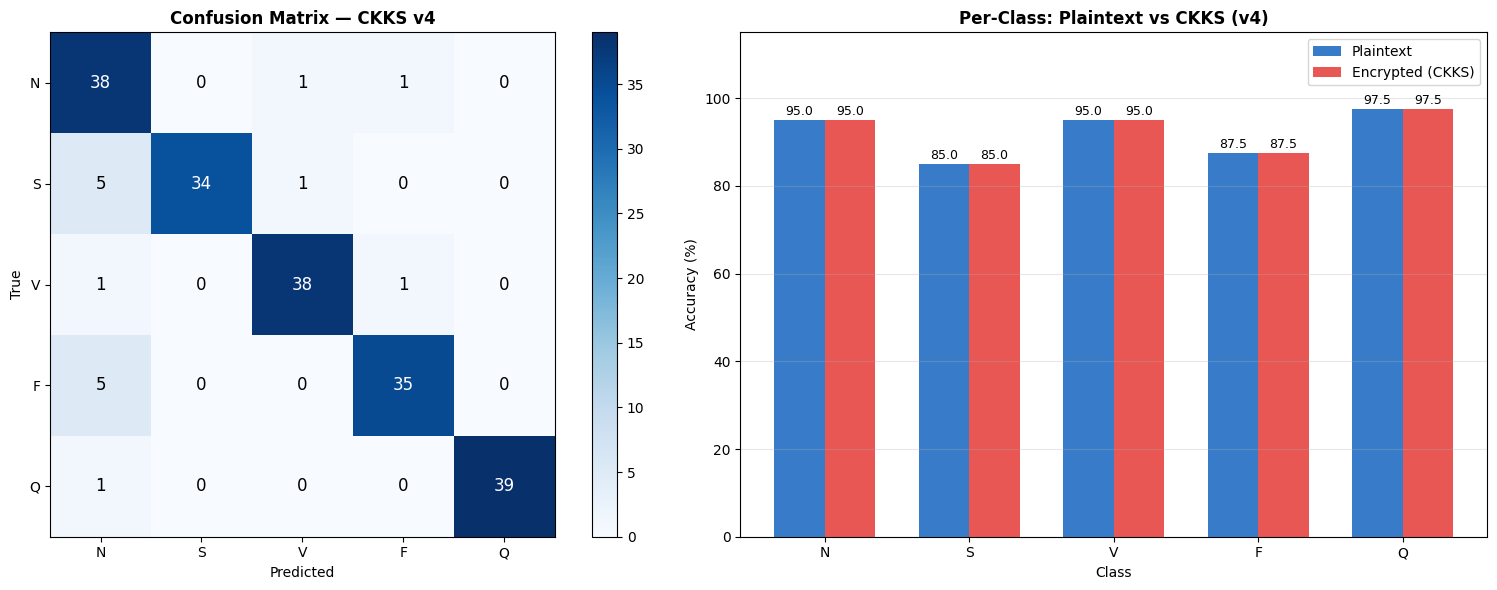


              precision    recall  f1-score   support

           N       0.76      0.95      0.84        40
           S       1.00      0.85      0.92        40
           V       0.95      0.95      0.95        40
           F       0.95      0.88      0.91        40
           Q       1.00      0.97      0.99        40

    accuracy                           0.92       200
   macro avg       0.93      0.92      0.92       200
weighted avg       0.93      0.92      0.92       200


Per-Class Accuracy Drop:
  N: Plain=95.0% Enc=95.0% Drop=+0.0pp
  S: Plain=85.0% Enc=85.0% Drop=+0.0pp
  V: Plain=95.0% Enc=95.0% Drop=+0.0pp
  F: Plain=87.5% Enc=87.5% Drop=+0.0pp
  Q: Plain=97.5% Enc=97.5% Drop=+0.0pp


In [16]:
cm = confusion_matrix(y_true_subset, y_enc_preds)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix
ax = axes[0]
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.set_title('Confusion Matrix — CKKS v4', fontweight='bold')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(CLASS_LABELS); ax.set_yticklabels(CLASS_LABELS)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=12)

# Per-class accuracy comparison
ax = axes[1]
per_class_plain_acc = []
per_class_enc_acc   = []
for cls in range(N_CLASSES):
    mask  = y_true_subset == cls
    p_acc = accuracy_score(y_true_subset[mask], y_plain_subset[mask])
    e_acc = accuracy_score(y_true_subset[mask], y_enc_preds[mask])
    per_class_plain_acc.append(p_acc)
    per_class_enc_acc.append(e_acc)

x = np.arange(N_CLASSES); w = 0.35
bars_p = ax.bar(x - w/2, [a*100 for a in per_class_plain_acc], w,
                label='Plaintext', color='#1565C0', alpha=0.85)
bars_e = ax.bar(x + w/2, [a*100 for a in per_class_enc_acc],   w,
                label='Encrypted (CKKS)', color='#E53935', alpha=0.85)
for bar in list(bars_p) + list(bars_e):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Class'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class: Plaintext vs CKKS (v4)', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(CLASS_LABELS)
ax.set_ylim(0, 115); ax.legend(); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('confusion_and_accuracy_v4.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + classification_report(y_true_subset, y_enc_preds, target_names=CLASS_LABELS))
print('\nPer-Class Accuracy Drop:')
for cls in range(N_CLASSES):
    drop = (per_class_plain_acc[cls] - per_class_enc_acc[cls]) * 100
    print(f'  {CLASS_LABELS[cls]}: Plain={per_class_plain_acc[cls]*100:.1f}% '
          f'Enc={per_class_enc_acc[cls]*100:.1f}% Drop={drop:+.1f}pp')